# Project - Mental Health in the Tech Industry 

## About

In this notebook we will be exploring the [mental health dataset](https://www.kaggle.com/datasets/anth7310/mental-health-in-the-tech-industry/data) from kaggle.

**We definded a Guiding Question for this Analysis:**

`What factors in the Tech Industry are associated with a higher likelihood of reporting mental health issues? - differentiating between self reported current conditions (undiagnosed and diagnosed) and formally diagnosed issues/disorders (current or past)`

Reporting ≠ Affected: cause based on our data we can only evaluate the ones that admit or got diagnosed, assuming the diagnosed ones admit. 
Nonetheless, we can subsequently explore what these reporting patterns suggest about the underlying affectedness by mental health issues in the tech industry.

## Connect the Dataset and Overview of the Dataset

**First we import the necessary modules, functions and all query constants from the Queries package needed:**

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import numpy as np
from scipy.stats import chi2

In [2]:
from Analysis.consts import MENTAL_HEALTH_DATASET_PATH
from Analysis.Queries.sociodemograhic_queries import (
    QUERY_AGE,
    QUERY_GENDER,
    QUERY_COUNTRY,
    QUERY_RACE,
)
from Analysis.Queries.sociodemograhic_influence_queries import (
    QUERY_GENDER_SELF,
    QUERY_GENDER_DIAG,
    QUERY_AGE_SELF,
    QUERY_AGE_DIAG,
    QUERY_FAM_SELF,
    QUERY_FAM_DIAG,
    QUERY_FAM_NON_SELF,
    QUERY_FAM_NON_DIAG,
)
from Analysis.Queries.workplace_influence_queries import (
    QUERY_RES_SELF,
    QUERY_RES_DIAG,
    QUERY_PLC_SELF,
    QUERY_PLC_DIAG,
)
from Analysis.Queries.single_diseases_query import QUERY_DISORDER
from Analysis.Queries.social_influence_queries import QUERY_SOCIAL_SELF, QUERY_CONT

We use a copy of our dataset to leave the original one untouched.

In [3]:
shutil.copy(MENTAL_HEALTH_DATASET_PATH, 'Dataset/mental_health_copy.sqlite')
conn = sqlite3.connect('Dataset/mental_health_copy.sqlite')
cursor = conn.cursor()

In [4]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print("Table Overview of the Dataset:")
for table in tables:
    print(f"- {table[0]}")

Table Overview of the Dataset:
- Answer
- Question
- Survey


**We successfully connected the dataset and see that our dataset consists of the three tables: Answer, Question, Survey.**

### Data Cleaning

In [5]:
query_clean = """
DELETE FROM Answer
WHERE AnswerText = '-1';
"""

cursor.execute(query_clean)

conn.commit()

Later our queries include validation to ensure only valid values are processed.

## Overview of the respondents of the survey

**We now get a brief overview of the dataset looking at the respondents of the survey.**

We will take a look at the sample size - Number of respondents as well as the main sociodemographic features of the respondents: 
- Age
- Gender
- Country
- Race

### Sample Size

In [6]:
query = """
SELECT DISTINCT UserID FROM Answer
"""
cursor.execute(query)
unique_user_ids = cursor.fetchall()
print(f"Our Sample size - Number of respondents: {len(unique_user_ids)}")

Our Sample size - Number of respondents: 4218


### What are the sociodemographic features of the respondents? - Age, Gender, Country, Race

### Age

We split the respondents into age groups to get a better overview and to exclude anomalies, namely we differentiate between: 18-24, 25-34, 35-44, 45-54, 55-64 and 65+. 

We will observe both the Total age distribution looking at all survey years along with the age distribution by age group by survey year to also get a sense of possible trends. 

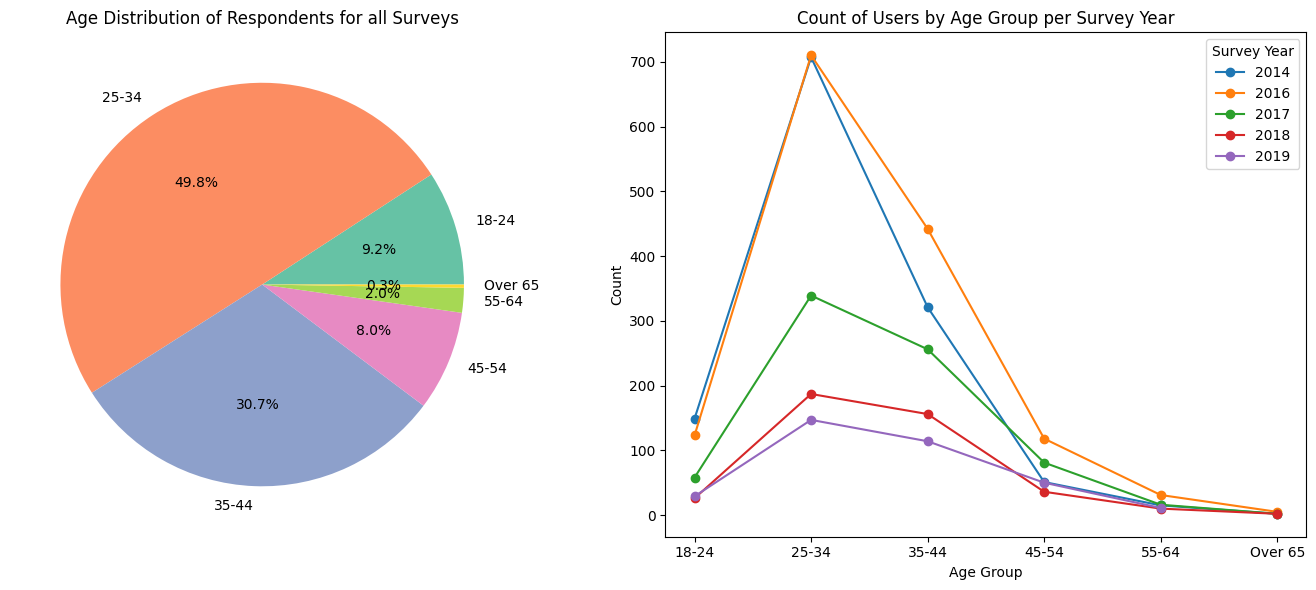

In [7]:
df_age = pd.read_sql(QUERY_AGE, conn)

df_total = df_age.groupby("age_group", as_index=False)["count"].sum()

colors = sns.color_palette("Set2", n_colors=len(df_total))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(
    df_total["count"], labels=df_total["age_group"], autopct="%.1f%%", colors=colors
)
axes[0].set_title("Age Distribution of Respondents for all Surveys")

for survey in df_age["SurveyID"].unique():
    subset = df_age[df_age["SurveyID"] == survey]
    axes[1].plot(subset["age_group"], subset["count"], marker="o", label=survey)

axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].set_title("Count of Users by Age Group per Survey Year")
axes[1].legend(title="Survey Year")

plt.tight_layout()
plt.show()

The majority of the respondents for all the surveys are between 25-34 years old with ~50% and roughly 30% are in the range of 35-44 years. The tiny minorities are over 55 ~2.3%. 

Inspecting the differentiation by survey year we can see this distribution as pattern is consistently reflected across all survey years. The years 2014 and 2016, however, stand out with particularly pronounced peaks in the 25–34 and 35–44 groups, whereas from 2017 onwards the distribution flattens and becomes more balanced across age groups, even though the 25–34 group remains dominant.  

### Gender

We first get a quick overview of the answer values to the gender question to consider the most relevant ones as well as some answer variations for the filtering process. 

In [8]:
cursor.execute(
    "SELECT a.AnswerText, COUNT(*) FROM Answer a WHERE QuestionID = 2 GROUP BY a.AnswerText ORDER BY COUNT(*) DESC"
)
gender_counts = cursor.fetchall()
print(f"Gender answers of respondents (Answer, count): \n{gender_counts[:10]}")

Gender answers of respondents (Answer, count): 
[('Male', 2830), ('Female', 914), ('male', 212), ('female', 110), ('Nonbinary', 8), ('non-binary', 6), ('Genderqueer', 4), ('Agender', 4), ('None', 3), ('Non-binary', 3)]


We see that mainly male, female and non-binary genders are represented. We will therefore from now on differentiate between these three groups, including Other to summarize the remaining ones.

In [9]:
df_gender = pd.read_sql(QUERY_GENDER, conn)
df_gender

,gender,count
0,Male,3053
1,Female,1037
2,Other,71
3,Non-Binary,29


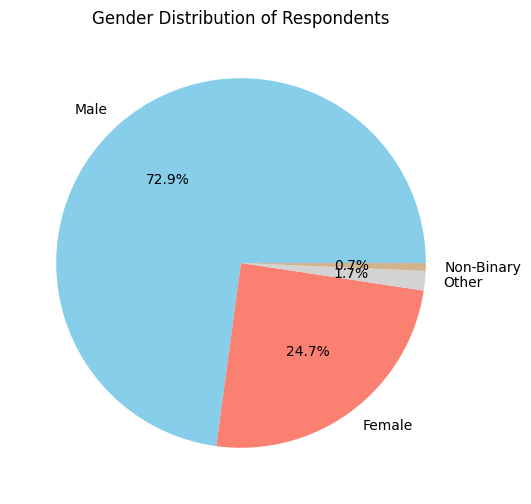

In [10]:
plt.figure(figsize=(8, 6))
plt.pie(
    df_gender["count"],
    labels=df_gender["gender"],
    autopct="%1.1f%%",
    colors=["skyblue", "salmon", "lightgray", "tan"],
)
plt.title("Gender Distribution of Respondents")
plt.show()

The majority of the respondents are Male ~73% with a total of 3053 respondents. Roughly 1/4 are Female and only a tiny minority is Non-Binary or Other with 2.4% - 100 respondents.

### Country

We first take a look at the answers including their format for the country question to safely handle the different formats.

In [11]:
cursor.execute(
    "SELECT a.AnswerText, COUNT(*) FROM Answer a WHERE QuestionID = 3 GROUP BY a.AnswerText ORDER BY COUNT(*) DESC"
)
country_counts = cursor.fetchall()
print(f"Country answers of respondents (Answer, count): \n{country_counts[:10]}")

Country answers of respondents (Answer, count): 
[('United States of America', 1853), ('United States', 751), ('United Kingdom', 482), ('Canada', 199), ('Germany', 136), ('Netherlands', 98), ('Australia', 73), ('Ireland', 51), ('France', 51), ('India', 50)]


Looking at the most common - Top10 - answers, the answers mainly seem to follow a consistent pattern. For the USA we have to consider the appearing of spelling variations.   

In [12]:
df_country = pd.read_sql(QUERY_COUNTRY, conn)

For the sake of clarity we unite all countries that appear less than 5 times in a seperate category Other.

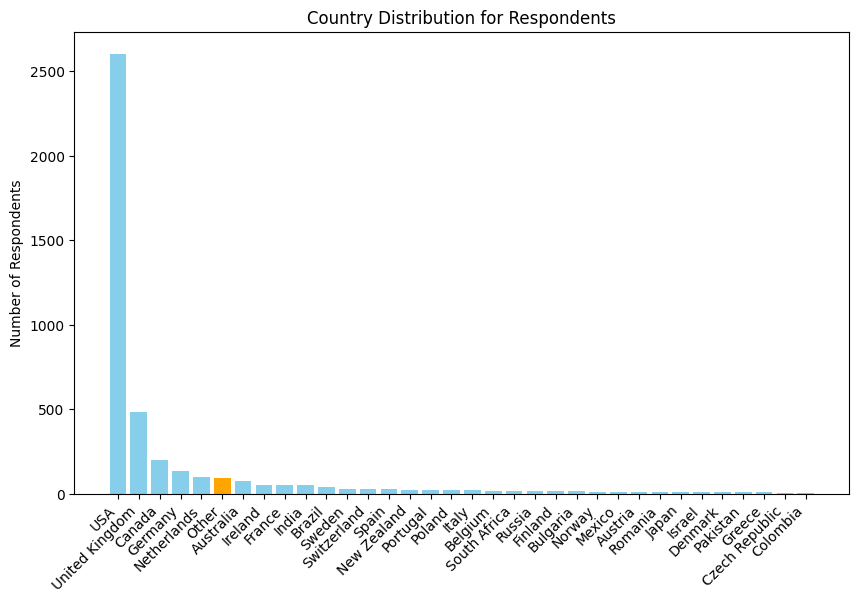

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(
    df_country["country"],
    df_country["count"],
    color=["orange" if c == "Other" else "skyblue" for c in df_country["country"]],
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Respondents")
plt.title("Country Distribution for Respondents")
plt.show()

We clearly see the dominance of the USA as the large majority with ~2600 respondents, followed at a distance by the United Kingdom, Canada, Germany and the Netherlands with the number of respondents being in the range 100-500. 

Most of the other countries only contribute in small numbers with less than 100 respondents. The category Other summarizes to 94 respondents, from countries with fewer than five appearances.  

### Race

We first observe the most common race answers to get sense of them. 

In [14]:
cursor.execute(
    "SELECT a.AnswerText, COUNT(*) FROM Answer a WHERE QuestionID = 89 GROUP BY a.AnswerText ORDER BY COUNT(*) DESC"
)
race_counts = cursor.fetchall()
print(f"Race answers of respondents (Answer, count): \n{race_counts[:10]}")

Race answers of respondents (Answer, count): 
[('White', 873), ('More than one of the above', 35), ('Asian', 31), ('I prefer not to answer', 29), ('Black or African American', 15), ('White Hispanic', 1), ('Hispanic', 1), ('European American', 1), ('Caucasian', 1), ('American Indian or Alaska Native', 1)]


In [15]:
df_race = pd.read_sql(QUERY_RACE, conn)

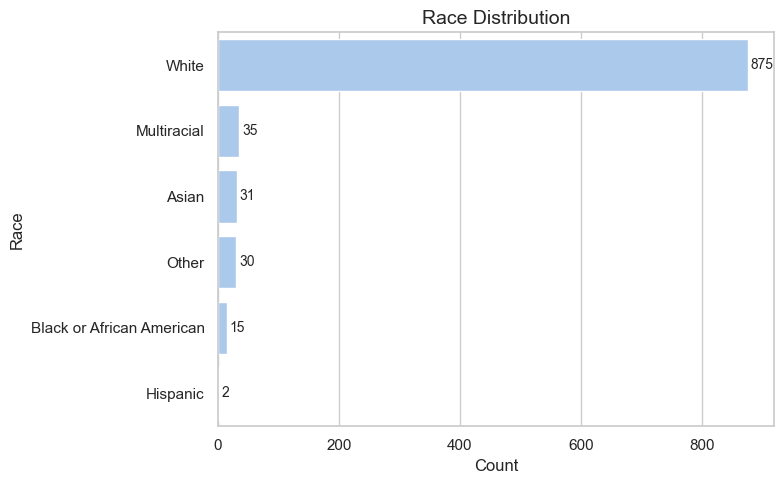

In [16]:
sns.set_theme(style="whitegrid")

f, ax = plt.subplots(figsize=(8, 5))
sns.set_color_codes("pastel")

sns.barplot(y="race", x="count", data=df_race, color="b", orient="h")
ax.set_xlabel("Count", fontsize=12)
ax.set_ylabel("Race", fontsize=12)
ax.set_title("Race Distribution", fontsize=14)

for i, v in enumerate(df_race["count"]):
    ax.text(v + 5, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()

The large majority of respondents that answered this question are white with 875, followed at a huge distance by Multiracial, Asians and the ones that preffered not to answer - all with ~30 respondents.  

### Do you see any evidence of sampling bias? 
**Is this dataset of surveys represantive for the tech industry as a whole?** 

In order to better understand the underlying distributions, it is generally advisable to analyze the data by subgroups such as survey year, country, race, or region. In some parts of our analysis, we have already taken this approach. Nonetheless more data here would definitely improve the analysis as well as the evaluation of the bias. 

The United States is heavily overrepresented compared to the global distribution of tech workers, and junior employees make up a larger share of responses than senior ones. Similarly, white and male respondents are disproportionately present. These imbalances mean that the survey cannot be considered fully representative of the tech industry as a whole. 
So there is clear evidence of sampling bias in the dataset.

We therefore in the rest of the analysis mainly take the prevalence rates for comparisons to ensure fair and valid comparisons between categories.

## Exploratory Data Analysis

**We will now iteratively raise Hypothesis to come to a conclusion differentiating between the areas:**
- Sociodemographic influence
- Workplace influence
- Social influence

### Sociodemographic Influence

**Hypothesis 1: Mental health issues are reported differently across genders.**

As seen before male respondents are overrepresented compared to female ones, therefore we can't simply look at the number of reports, we rather take the prevalence rate of reports. Due to the domination of male and female in the dataset, we simply connsider these two genders. 
Also we differentiate between the survey years to get inisghts about possible trends over time.

We differentiate between self reported issues/disorders and diagnosed ones.

We start with the self reported current condition ones regarding to the question: Do you currently have a mental health disorder?

In [17]:
df_self = pd.read_sql(QUERY_GENDER_SELF, conn)
df_self

,survey_year,gender,count,total,percent
0,2016,Female,180,336,53.57
1,2016,Male,367,1057,34.72
2,2017,Female,120,218,55.05
3,2017,Male,181,502,36.06
4,2018,Female,71,125,56.80
5,2018,Male,106,266,39.85
6,2019,Female,53,98,54.08
7,2019,Male,81,227,35.68


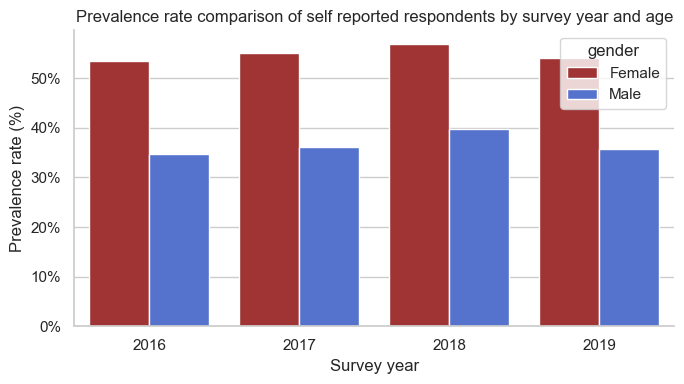

In [18]:
palette = {"Male": "royalblue", "Female": "firebrick"}

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=df_self, x="survey_year", y="percent", hue="gender", palette=palette
)
ax.set_xlabel("Survey year")
ax.set_ylabel("Prevalence rate (%)")
ax.set_title(
    "Prevalence rate comparison of self reported respondents by survey year and age"
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

We see that the prevalence of female respondents self reporting mental issues (\~53-56%) is clearly higher than the one for male respondents  (~35-40%) for all years observed. Looking at trend from years 2016 - 2019 we basically see the same pattern for both male and female respondents, they both have their peak in 2018 with 56.8% for female and 39.85% for male. 

The temporal pattern shows relatively stable rates across the four-year period, with only minor fluctuations. For females, rates remain consistently in the mid-50% range, while males maintain rates in the mid-to-upper 30% range. The consistent ~20 percentage point gap between genders across all years suggests this is a persistent pattern rather than a temporary phenomenon.
We have to consider that male respondents may also have mental health issues but are less likely to admit and self-report their current status - we would need more data to draw a definitive conclusion. 

However, we can nonetheless conclude that female respondents tend to report mental health issues more than male ones, which suggests the hypothesis that females may be more affected by mental health conditions. To strengthen this hypothesis, we will now examine the diagnosed disorder data.

We continue with the question: Have you ever been diagnosed with a mental health disorder?

In [19]:
df_diag = pd.read_sql(QUERY_GENDER_DIAG, conn)
df_diag

,survey_year,gender,count,total,percent
0,2016,Female,218,336,64.88
1,2016,Male,467,1057,44.18
2,2017,Female,116,218,53.21
3,2017,Male,176,502,35.06
4,2018,Female,70,125,56.00
5,2018,Male,105,266,39.47
6,2019,Female,53,98,54.08
7,2019,Male,78,227,34.36


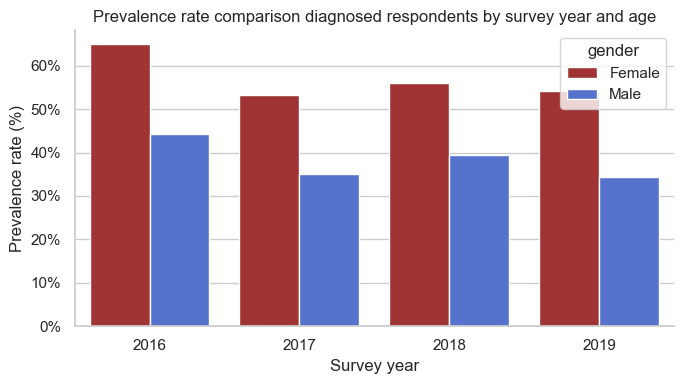

In [20]:
palette = {"Male": "royalblue", "Female": "firebrick"}

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=df_diag, x="survey_year", y="percent", hue="gender", palette=palette
)
ax.set_xlabel("Survey year")
ax.set_ylabel("Prevalence rate (%)")
ax.set_title("Prevalence rate comparison diagnosed respondents by survey year and age")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

Here we also clearly observe a female predominance, with diagnosed rates ranging from 53-65% for females compared to 34-44% for males across the survey years. Notably, the gender disparity appears even more pronounced in diagnosed cases than in self-reported ones. The diagnosed data shows more volatility, particularly for females, with a notable peak of 65% in 2016 followed by a decline to more stable levels around 53-56% in subsequent years.

This strengthens our hypothesis that females experience higher rates of mental health issues, but also reveals a more complex picture than initially suggested. Rather than simply being more willing to self-report, females appear to have genuinely higher diagnosed prevalence rates, indicating they may indeed be more affected by mental health conditions than males in this population.

Interestingly, when comparing self-reported versus diagnosed rates (diagnosed is related to diagnosed at sometime, not neccesarly now), we find that female diagnosed rates (53-65%) are often higher than their self-reported rates (53-57%), while male rates remain relatively consistent between both measures. This pattern suggests that some females who have received clinical diagnoses at some point in their lives may not currently consider themselves as having mental health issues when self-reporting. This could indicate either recovery or/and effective treatment.

**Conclusion:**

Therefore our initial hypothesis: Mental health issues are reported differently across genders - is clearly proven with females having higher rates of self report as well as diagnosed mental disorders, which indeed suggests that females tend to be more affected.

**Hypothesis 2: 25-34 year olds are more likely to report mental health issues.**

As seen before younger age groups (junior roles) are overrepresented compared to older age groups (senior roles), therefore we can't simply look at the number of reports, we rather take the prevalence rate of reports for all age groups.
Also we distinguish between the survey years to get inisghts about possible trends over time.

We again differentiate between self reported current issues/disorders and formally diagnosed ones.

In [21]:
df_age_self = pd.read_sql(QUERY_AGE_SELF, conn)

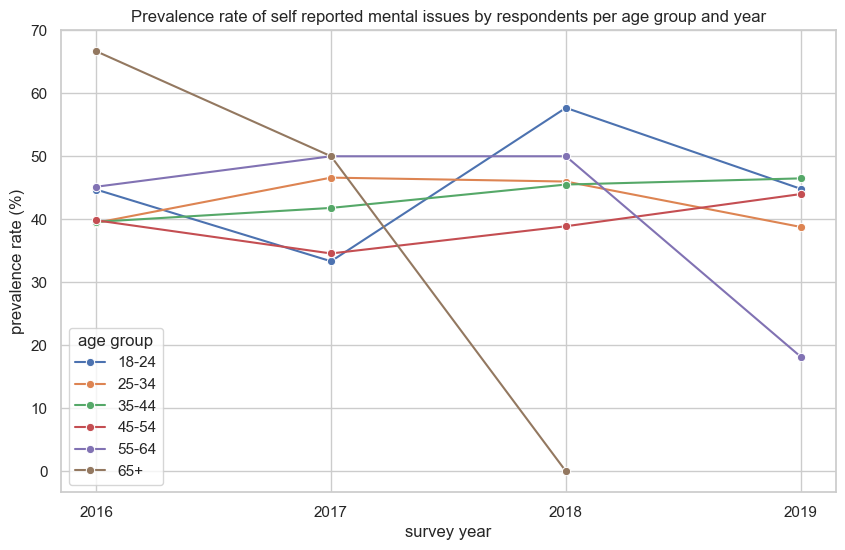

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_age_self, x="survey_year", y="percent", hue="age_group", marker="o"
)

plt.title(
    "Prevalence rate of self reported mental issues by respondents per age group and year"
)
plt.ylabel("prevalence rate (%)")
plt.xlabel("survey year")
plt.legend(title="age group")
plt.grid(True)
plt.xticks(sorted(df_age_self["survey_year"].unique()))
plt.show()

The data reveals a clear age gradient, with younger adults consistently reporting higher rates than older groups. The 18-24 age group shows the most volatility, ranging from 33% to 57%, with a peak in 2018. The 25-34 and 35-44 groups maintain relatively stable rates between 35-47% throughout the period, while the 45-54 group shows a gradual increase from 39% to 44%. Most notably, the older age groups (55+ and 65+) exhibit extreme patterns, with the 65+ group declining from 66% in 2016 to nearly 0% by 2018, and the 55-64 group dropping to 18% in 2019 - which is mainly caused by the fact that there were just a few respondents for the survey for these groups. 

Overall, the plot shows that prevalence is generally split in a balanced way with a trend of: younger adults are more likely to report mental health issues, with rates generally decreasing with age.
Concerning our hypothesis we can't say that the prevalence rate of 25-34 year olds shows more likelihood regarding self reported current conditions respondents.

We will now examine the prevalence rate of diagnosed ones.

In [23]:
df_age_diag = pd.read_sql(QUERY_AGE_DIAG, conn)

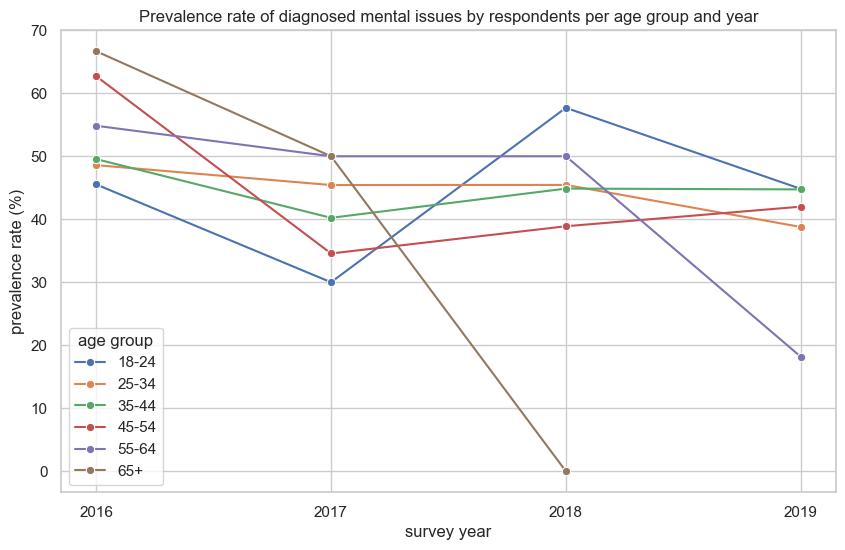

In [24]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_age_diag, x="survey_year", y="percent", hue="age_group", marker="o"
)

plt.title(
    "Prevalence rate of diagnosed mental issues by respondents per age group and year"
)
plt.ylabel("prevalence rate (%)")
plt.xlabel("survey year")
plt.legend(title="age group")
plt.grid(True)
plt.xticks(sorted(df_age_diag["survey_year"].unique()))
plt.show()

The prevalence rates of diagnosed issues also support a rather balanced view, with 18-24 being the most extreme. Nonetheless we can clearly observe the trend of decreasing prevalence rates for higher ages - 55-64, 65+ cause here the graphs are constantly decreasing in our time frame.

**Conclusion:**

The observations show that the prevalence rates are more balanced between age groups with a trend to younger ones, but not only and necessarily 25-34 year olds, for both self reported and diagnosed. Therefore the hypothesis is'nt supported by our data. 

**Hypothesis 3: People with a Family Background of mental health issues are more likely to report mental health issues.**

We will now observe the influence of family regarding the question: Do you have a family history of mental illness?

We again distinguish between self reported current and formally diagnosed disorders.

**We observe: From all people that self-report having/ admit getting diagnosed with mental health issues, how is the distribution of their family background?**

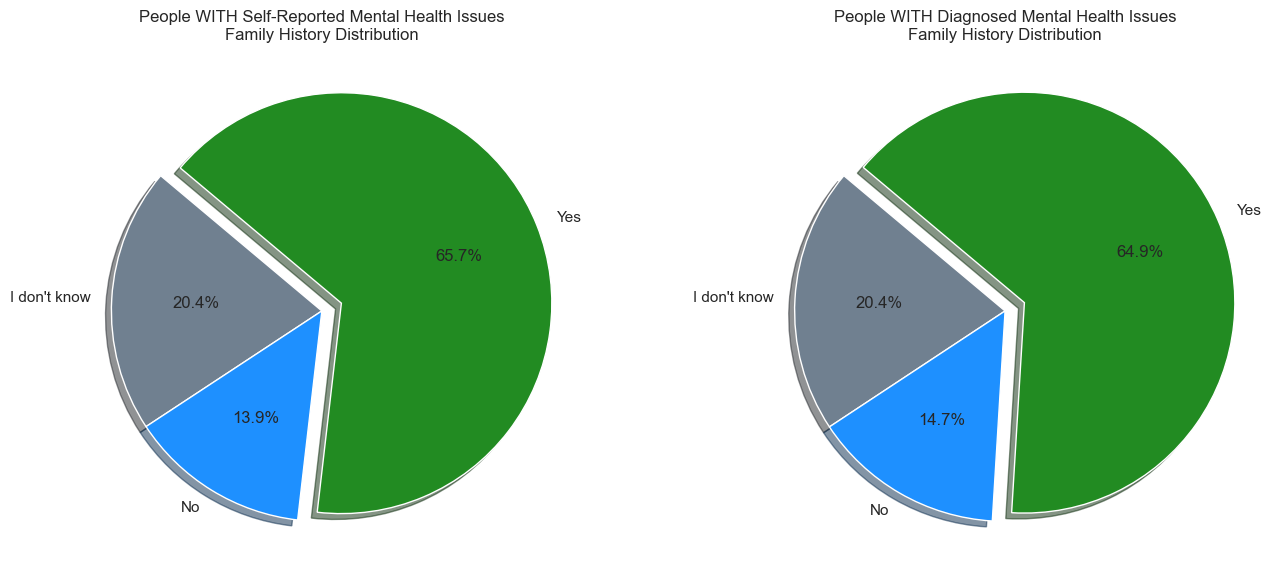

In [25]:
df_fam_self = pd.read_sql(QUERY_FAM_SELF, conn)
df_fam_diag = pd.read_sql(QUERY_FAM_DIAG, conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ["slategray", "dodgerblue", "forestgreen"]
explode = (0, 0, 0.1)
ax1.pie(
    df_fam_self["percentage"],
    labels=df_fam_self["family_history"],
    explode=explode,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
)
ax1.set_title(
    "People WITH Self-Reported Mental Health Issues\nFamily History Distribution"
)

explode = (0, 0, 0.1)
ax2.pie(
    df_fam_diag["percentage"],
    labels=df_fam_diag["family_history"],
    explode=explode,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
)
ax2.set_title("People WITH Diagnosed Mental Health Issues\nFamily History Distribution")

plt.tight_layout()
plt.show()

On the left we plotted the self reported family background distribution and on the right the diagnosed one. 

This shows that among people with mental health issues (both self-reported and diagnosed), a large majority (65%) have a family background of mental illness. The nearly identical distributions between self-reported and diagnosed cases suggest that family history is strongly correlated with reported mental health issues.

However, to fully prove our hypothesis, we would need to compare this with the family background distribution of people without mental health issues. If that group shows significantly lower rates of family history, then our hypothesis would be strongly supported. 
Therefore we do that now.

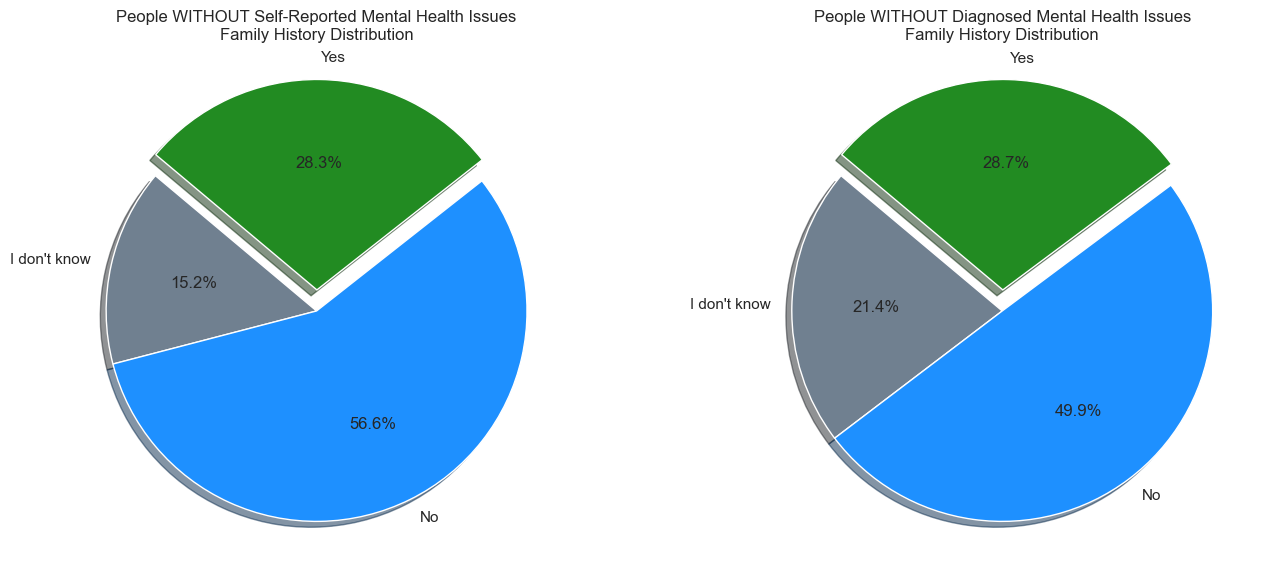

In [26]:
df_fam_non_self = pd.read_sql(QUERY_FAM_NON_SELF, conn)
df_fam_non_diag = pd.read_sql(QUERY_FAM_NON_DIAG, conn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ["slategray", "dodgerblue", "forestgreen"]
explode = (0, 0, 0.1)
ax1.pie(
    df_fam_non_self["percentage"],
    labels=df_fam_non_self["family_history"],
    explode=explode,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
)
ax1.set_title(
    "People WITHOUT Self-Reported Mental Health Issues\nFamily History Distribution"
)

colors = ["slategray", "dodgerblue", "forestgreen"]
explode = (0, 0, 0.1)
ax2.pie(
    df_fam_non_diag["percentage"],
    labels=df_fam_non_diag["family_history"],
    explode=explode,
    colors=colors,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
)
ax2.set_title(
    "People WITHOUT Diagnosed Mental Health Issues\nFamily History Distribution"
)

plt.tight_layout()
plt.show()

As suspected we observe significantly lower rates of family history, for both self reported and diagnosed. 

The "Yes" percentage - family background with mental illness - dropped in both cases from 65% to 30% and the "No" percentage - no family background with mental illness - has more than tripled from 14 - (50 - 56%). 

**Conclusion:**

Therefore the hypothesis: People with a Family Background of mental health issues are more likely to report mental health issues - is supported. 

### Workplace Influence

**Hypothesis 4: People with access to mental health resources at their current company are less likely to report.** 

Now we take a look at the workplace influence starting with the hypothesis regarding the question: Does your employer offer resources to learn more about mental health disorders and options for seeking?

In both cases we will also differentiate between the different survey years to get insights on possible trends.

We start with the self reported current case.

In [27]:
df_res_self = pd.read_sql(QUERY_RES_SELF, conn)

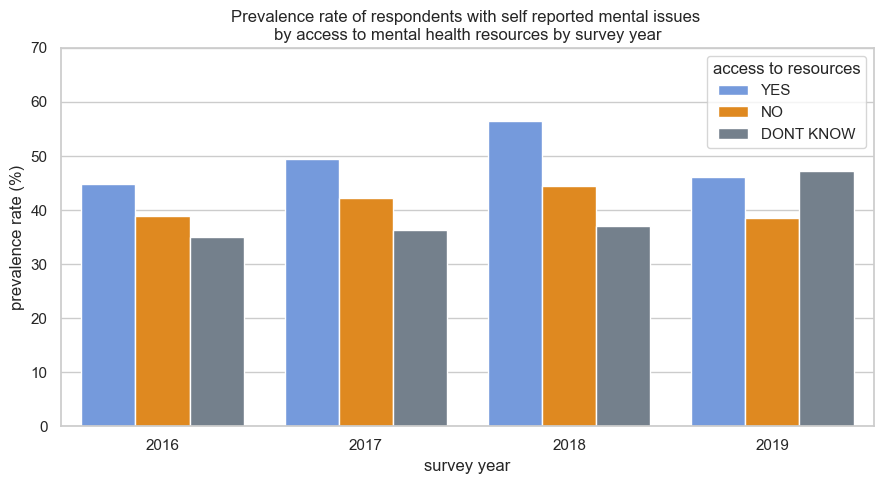

In [28]:
sns.set(style="whitegrid")
colors = ["cornflowerblue", "darkorange", "slategray"]

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_res_self,
    x="survey_year",
    y="percent",
    hue="access",
    hue_order=["YES", "NO", "DONT KNOW"],
    dodge=True,
    palette=colors,
)
ax.set_ylim(0, 70)
ax.set_xlabel("survey year")
ax.set_ylabel("prevalence rate (%)")
ax.legend(title="access to resources", loc="best")
plt.title(
    "Prevalence rate of respondents with self reported mental issues \nby access to mental health resources by survey year"
)
plt.tight_layout()
plt.show()

In the years 2016 - 2017 we see a clear pattern with the "Yes" respondents, so the respondents that got access to resources leading the prevalence rate of self reported issues with ~45%, 50% and 55% followed by the "NO" group and the "DONT KNOW" group as the last one. 
We also see the pattern of raising prevalence rates in this time period for all groups. 
A kind of an outlier is the year 2019 with more balanced prevalence rates and "DONT KNOW" as leading group.
So it seems that actually the ones that got access to resources are admitting more likely than the ones without for self report, contradictory to our hypothesis.

We now examine the diagnosed rates.

In [29]:
df_res_diag = pd.read_sql(QUERY_RES_DIAG, conn)

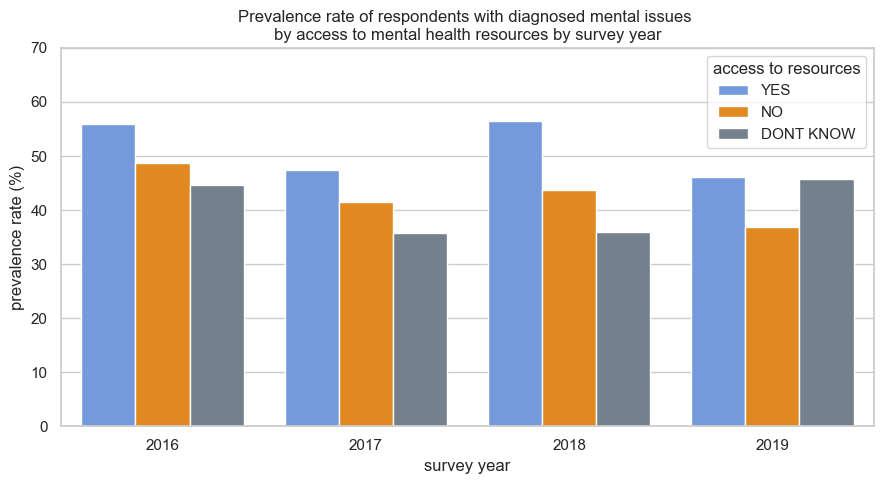

In [30]:
sns.set(style="whitegrid")
colors = ["cornflowerblue", "darkorange", "slategray"]

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_res_diag,
    x="survey_year",
    y="percent",
    hue="access",
    hue_order=["YES", "NO", "DONT KNOW"],
    dodge=True,
    palette=colors,
)
ax.set_ylim(0, 70)
ax.set_xlabel("survey year")
ax.set_ylabel("prevalence rate (%)")
ax.legend(title="access to resources", loc="best")
plt.title(
    "Prevalence rate of respondents with diagnosed mental issues \nby access to mental health resources by survey year"
)
plt.tight_layout()
plt.show()

Here we basically observe the same pattern with "YES" as the leading group in all years and a clear distinction from the "NO" group with a minimum of ~5-10%.
So also in the diagnosed case, the ones that got access are more likely to report their diagnosis.

**Conclusion:**

The respondents that got access to resources are actually more likely to report. Therefore our hypothesis is not supported by our data.

**Hypothesis 5: Office vs. Remote affects reporting.**

In our dataset are two important questions regarding this topic, unfortunately only one can be used.
The question: Do you work remotely (outside of an office) at least 50% of the time? would help us evaluate, but it was only asked 2014 and the reporting questions were asked from 2016 onwards. Further data here would definetly sharpen the analysis.

Nonetheless we will examine: Do you work remotely? as a question distinguishing between self report current and formally diagnosed ones.

In [31]:
df_plc_self = pd.read_sql(QUERY_PLC_SELF, conn)

In [32]:
df_plc_diag = pd.read_sql(QUERY_PLC_DIAG, conn)

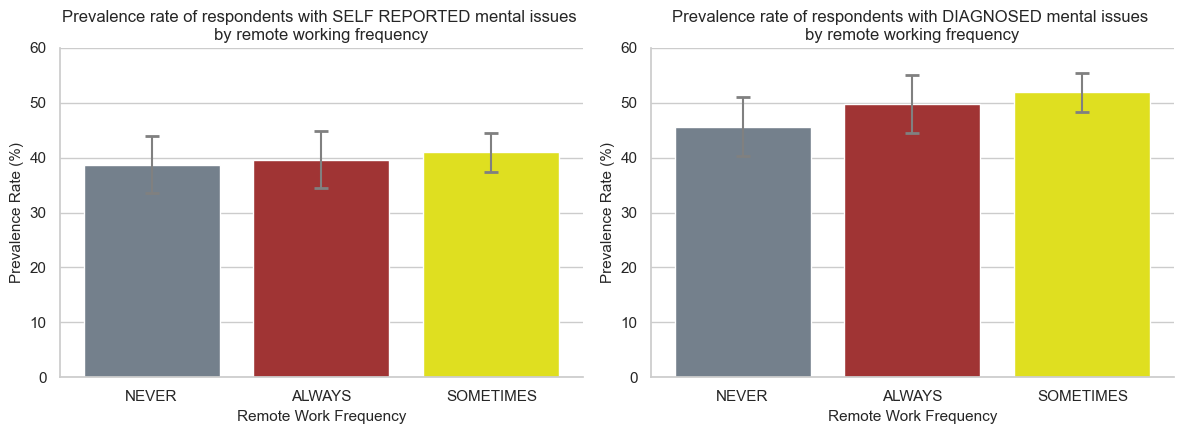

In [33]:
sns.set(style="whitegrid")
palette = ["slategray", "firebrick", "yellow"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(
    data=df_plc_self,
    x="remote_100",
    y="percent_100",
    palette=palette,
    errorbar=None,
    hue="remote_100",
    ax=ax1,
    legend=False,
)

plt.sca(ax1)
plt.errorbar(
    x=range(len(df_plc_self)),
    y=df_plc_self["percent_100"],
    yerr=[
        df_plc_self["percent_100"] - df_plc_self["ci_lower_percent_100"],
        df_plc_self["ci_upper_percent_100"] - df_plc_self["percent_100"],
    ],
    fmt="none",
    color="gray",
    capsize=5,
    capthick=2,
)

ax1.set_ylim(0, 60)
ax1.set_xlabel("Remote Work Frequency", fontsize=11)
ax1.set_ylabel("Prevalence Rate (%)", fontsize=11)
ax1.set_title(
    "Prevalence rate of respondents with SELF REPORTED mental issues \nby remote working frequency",
    fontsize=12,
)

sns.barplot(
    data=df_plc_diag,
    x="remote_100",
    y="percent_100",
    palette=palette,
    errorbar=None,
    hue="remote_100",
    ax=ax2,
    legend=False,
)

plt.sca(ax2)
plt.errorbar(
    x=range(len(df_plc_diag)),
    y=df_plc_diag["percent_100"],
    yerr=[
        df_plc_diag["percent_100"] - df_plc_diag["ci_lower_percent_100"],
        df_plc_diag["ci_upper_percent_100"] - df_plc_diag["percent_100"],
    ],
    fmt="none",
    color="gray",
    capsize=5,
    capthick=2,
)

ax2.set_ylim(0, 60)
ax2.set_xlabel("Remote Work Frequency", fontsize=11)
ax2.set_ylabel("Prevalence Rate (%)", fontsize=11)
ax2.set_title(
    "Prevalence rate of respondents with DIAGNOSED mental issues \nby remote working frequency",
    fontsize=12,
)
sns.despine(ax=ax1)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

For both rates we can inspect differences across remote work arrangements. For self-reported rates, the differences are minimal, ranging from 38.74% to 40.95%, and considering their 95% confidence intervals, these differences are not statistically significant as the intervals substantially overlap. In contrast, diagnosed rates show more pronounced differences, with rates increasing from 45.65% for those who never work remotely to 51.92% for those who sometimes work remotely, and the confidence intervals show less overlap, suggesting these differences may be meaningful.

**Conclusion:**

Remote vs. Office differences in reporting exist, but they tend to be not that big - although in the formally diagnosed case the ones that sometimes or always work remote tend to be more likely to report. 
Therefore our hypothesis: Office vs. Remote affects reporting - is partially supported. 

### Social influence

**Hypothesis 6: People that are more willing to share with friends and family that they have a mental illness, are more likely to self report.**

We now examine the social influence regarding the question:
How willing would you be to share with friends and family that you have a mental illness?

We will be exploring the self reported current ones.

**We are going to use the Chi-squared test to check whether there's statistical significant correlation between people sharing their illness with friends and family and their self report differentiating between the survey years to observe possible trends.**

Nullhypothesis: There is no association between willingness to share and self report

Alternative Hypothesis: There is an association

In [34]:
df_social_self = pd.read_sql(QUERY_SOCIAL_SELF, conn)
df_social_self["p_value"] = df_social_self.apply(
    lambda row: round(
        1 - chi2.cdf(row["chi2_statistic"], row["degrees_of_freedom"]), 8
    ),
    axis=1,
)
df_social_self

,survey_year,chi2_statistic,rows_k,degrees_of_freedom,p_value
0,2016,31.308800,5,4,0.000003
1,2017,44.725683,5,4,0.000000
2,2018,27.465502,5,4,0.000016
3,2019,16.421332,5,4,0.002503


We calculated a frequency table for willingness to share and self report.
Afterwards we calculated the expected frequencies and chi squared values per survey year. We can see the results in the table above.

We see that the chi squared statistic decreases over time, while the association remains statistically significant throughout all years, as we see based on all p-values < 0.01 - we have to reject the Nullhypothesis, the strength of the relationship between openness and self-reporting appears to be weakening over time.
Concerning the initial hypothesis, there is a correlation, the question is now in what direction.

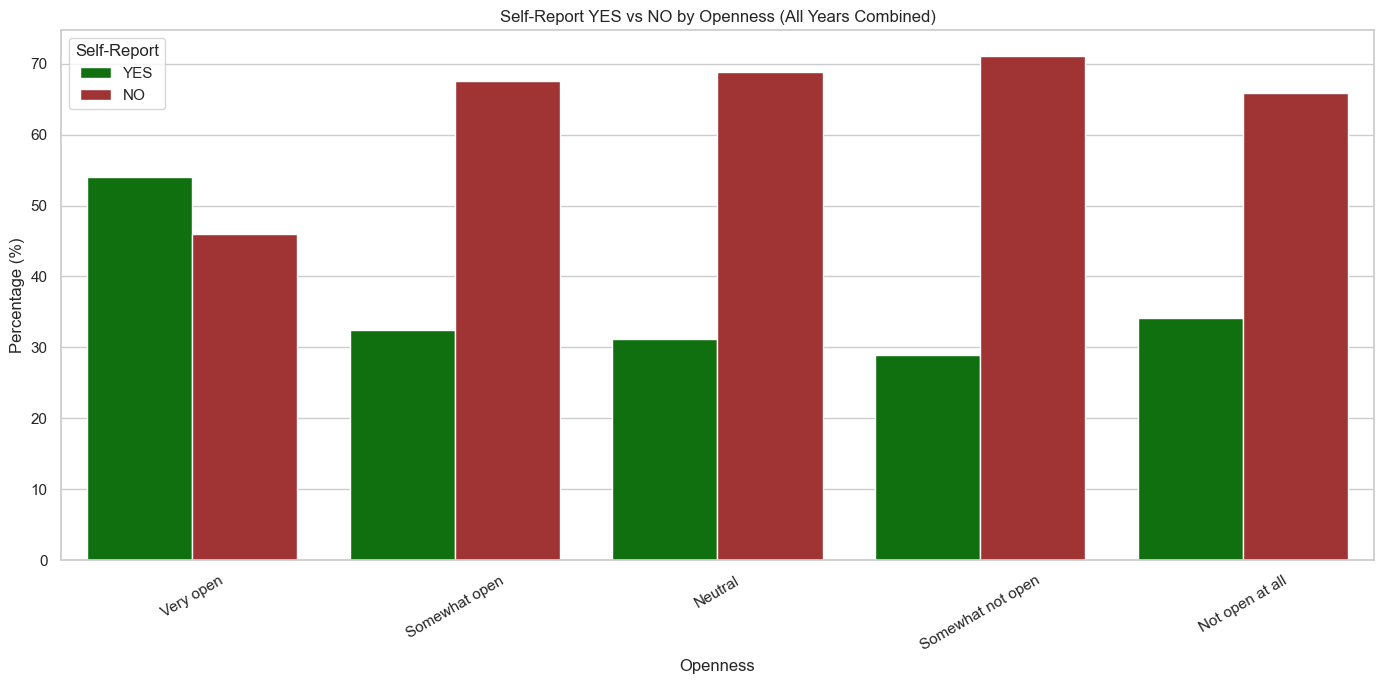

In [35]:
df_cont = pd.read_sql(QUERY_CONT, conn)
order = [
    "Very open",
    "Somewhat open",
    "Neutral",
    "Somewhat not open",
    "Not open at all",
]
colors = ["green", "firebrick"]

plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_cont,
    x="openness",
    y="percentage",
    hue="response",
    order=order,
    hue_order=["yes_count", "no_count"],
    errorbar=None,
    palette=colors,
)
plt.title("Self-Report YES vs NO by Openness (All Years Combined)")
plt.ylabel("Percentage (%)")
plt.xlabel("Openness")
plt.xticks(rotation=30)
plt.legend(title="Self-Report", labels=["YES", "NO"])
plt.tight_layout()
plt.show()

Looking at the distribution of Self report (Yes/No) for all Openness categories all years combined, we clearly see that the ones that are more open are more likely to self report and there's also the trend, the sooner they are not open the more they do not report.
Therefore: People that are more willing to share with friends and family that they have a mental illness, are more likely to self report their current condition.

**Conclusion:**

Our hypothesis is approved.

## Prevalence Rate of single mental diseases

**We will now report the prevalence rate of the three most common mental diseases in our dataset and plot their confidence intervals.**

In [36]:
cursor.execute(
    "SELECT a.AnswerText, COUNT(*) FROM Answer a WHERE QuestionID = 115 GROUP BY a.AnswerText ORDER BY COUNT(*) DESC"
)
disorders = cursor.fetchall()
print(disorders[:3])

[('Mood Disorder (Depression, Bipolar Disorder, etc)', 412), ('Anxiety Disorder (Generalized, Social, Phobia, etc)', 345), ('Attention Deficit Hyperactivity Disorder', 121)]


In [37]:
df_disorder = pd.read_sql(QUERY_DISORDER, conn)
df_disorder

,disease,count,n_total,prevalence_percent,ci_lower_percent,ci_upper_percent
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",412,568,72.54,68.86,76.21
1,"Anxiety Disorder (Generalized, Social, Phobia,...",345,568,60.74,56.72,64.76
2,Attention Deficit Hyperactivity Disorder,121,568,21.30,17.94,24.67


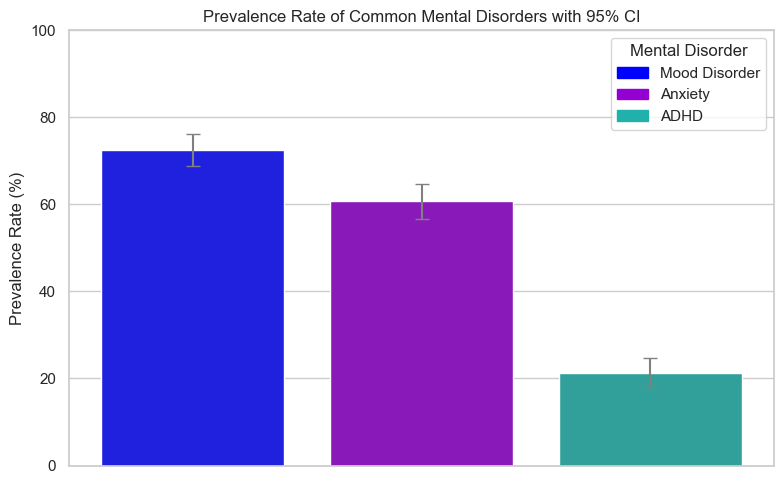

In [38]:
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))

colors = ["blue", "darkviolet", "lightseagreen"]

sns.barplot(
    x="disease",
    y="prevalence_percent",
    data=df_disorder,
    palette=colors,
    errorbar=None,
    capsize=0.1,
    legend=False,
    hue="disease",
)
plt.errorbar(
    x=range(len(df_disorder)),
    y=df_disorder["prevalence_percent"],
    yerr=[
        df_disorder["prevalence_percent"] - df_disorder["ci_lower_percent"],
        df_disorder["ci_upper_percent"] - df_disorder["prevalence_percent"],
    ],
    fmt="none",
    color="gray",
    capsize=5,
)
plt.ylim(0, 100)
ax = plt.gca()
ax.set_xticklabels([])
plt.xlabel("")
handles = [plt.Rectangle((0, 0), 0.3, 0.3, color=c) for c in colors]
plt.legend(handles, ["Mood Disorder", "Anxiety", "ADHD"], title="Mental Disorder")
plt.ylabel("Prevalence Rate (%)")
plt.title("Prevalence Rate of Common Mental Disorders with 95% CI")
plt.tight_layout()
plt.show()

**Interpretation:**

From the 568 people that answered this question (sample size):
- Diagnosed with **Mood disorder**: 412, prevalence rate: 72.54%, 95% confidence interval [68.86% - 76.21%]
- Diagnosed with **Anxiety disorder**: 345, prevalence rate: 60.74%, 95% confidence interval [56.72% - 64.76%]
- Diagnosed with **Attention deficit hyperactivity disorder**: 121, prevalence rate: 21.30%, 95% confidence interval [17.94% - 24.67%]

Which means that if we repeat the survey 100 times and get samples out of the total population - all tech workers that got diagnozed, in 95 times the prevalence would be inside that interval. In other words, we can say with 95 % confidence that the true prevalence of Mood Disorders, Anxiety Disorders, Attention Deficit Hyperactivity Disorders among all tech workers that got diagnozed lies between the limits of their confidence intervals.

## Final Conclusion

`What factors in the Tech Industry are associated with a higher likelihood of reporting mental health issues? - differentiating between self reported current conditions (undiagnosed and diagnosed) and formally diagnosed issues/disorders (current or past)`

### Final Summary

- Overview of respondents:
  - Survey years: 2014, 2016–2019, with three tables: Question, Answer and Survey
  - Cleaning: removed −1 entries

  - Sociodemograhic distribution: age concentrated in 25–34; gender majority male; USA prominent among countries; race dominated by white
  - Sampling bias: The United States is heavily overrepresented compared to the global distribution of tech workers, and junior employees make up a larger share of responses than senior ones. Similarly, white and male respondents are disproportionately present. These imbalances mean that the survey cannot be considered fully representative of the tech industry as a whole. So there is clear evidence of sampling bias in the dataset. 


- Prevalence of single mental diseases with 95% CIs:
  - Mood disorder: 72.54% [68.86% – 76.21%]
  - Anxiety disorder: 60.74% [56.72% – 64.76%]
  - ADHD: 21.30% [17.94% – 24.67%]
  - Interpretation: these are within‑sample estimates reported with confidence intervals to reflect sampling uncertainty

- Hypotheses:
  - H1 – Gender differences: Females tend to report more likely -> report influence
  - H2 – Age group differences: patterns vary across years; more balanced with a trend of decreasing reports the older the respondents -> limited influence
  - H3 – Family history: clearly higher rates among those with family history; counterfactual the ones without reporting show significant lower rates -> Family clearly influences reporting
  - H4 – Workplace resources: positive association -> definitely influences reporting
  - H5 – Remote vs office: self‑report shows small differences with overlapping CIs; diagnosed tends higher for sometimes/always remote with less overlap -> partially supported - moderate effect/ influence
  - H6 – Social openness: The association is statistically significant, ones that are more open are more likely to self report and there's also the trend, the sooner they are not open the more they do not report.
Therefore: People that are more willing to share with friends and family that they have a mental illness, are more likely to self report.


**Final conclusion:** 
Within sample, mood (72.5%), anxiety (60.7%), and ADHD (21.3%) disorders appear most common, though estimates are uncertain. Reporting is shaped less by sociodemographics and more by family history, workplace resources, and social openness, with remote work showing mixed effects. Clear sampling bias (overrepresentation of U.S., white, male, and junior employees) limits generalizability.

Limitations and Improvement of Analysis:
- Statistical tests
- More data - more respondents in a higher timeframe to further reduce sampling uncertainty; Dive even deeper by exploring more questions regarding the hypotheses
- Again to better ensure affectedness we'd need clear data about diagnosed cases rather than the uncertainty whether affected ones admit.